__How can we distinguish two cells are rbc and wbc ?__ \
Fisrt, we must to observe characteristics and realize that:  
- RBC has color like <ins>red</ins>
- WBC has color like <ins>purple</ins>

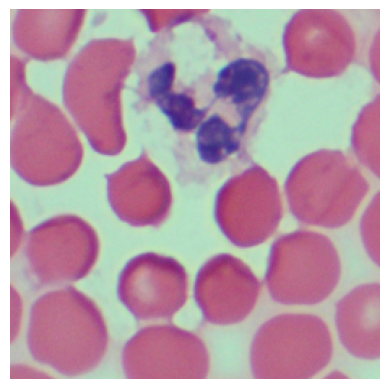

In [2]:
#Read Image
import cv2
import numpy as np
import matplotlib.pyplot as plt
img_name = 'dataset/BDS/images/image-1.png'
img = cv2.imread(img_name)
#Convert to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#Display Image
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

So, we need a mask to these task

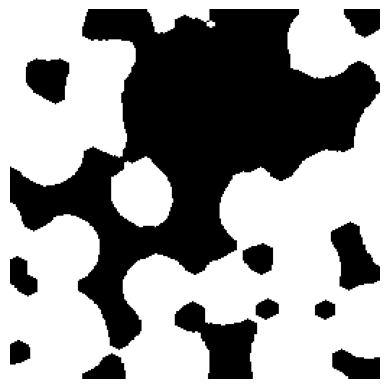

In [3]:
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
# Hue đỏ/hồng nằm ở 2 đầu vòng màu HSV (0-15 và 155-180)
rbc_mask1 = cv2.inRange(img_hsv, np.array([0,   40, 100]), np.array([15,  255, 255]))
rbc_mask2 = cv2.inRange(img_hsv, np.array([155, 40, 100]), np.array([180, 255, 255]))
rbc_mask  = cv2.bitwise_or(rbc_mask1, rbc_mask2)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
rbc_mask = cv2.morphologyEx(rbc_mask, cv2.MORPH_CLOSE, kernel, iterations=3)
rbc_mask = cv2.morphologyEx(rbc_mask, cv2.MORPH_OPEN,  kernel, iterations=1)

plt.imshow(rbc_mask, cmap='gray')
plt.axis('off')
plt.show()

Now, we will separate origin image into two image using mask \
First, Let's see rbc

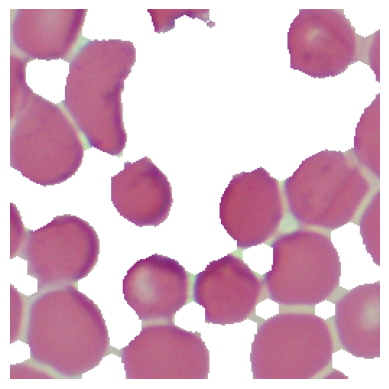

In [4]:
result_rbc = img.copy()
result_rbc[rbc_mask == 0] = 255
result_rbc_rbg = cv2.cvtColor(result_rbc, cv2.COLOR_BGR2RGB)
plt.imshow(result_rbc_rbg)
plt.axis('off')
plt.show()

Similiar to wbc

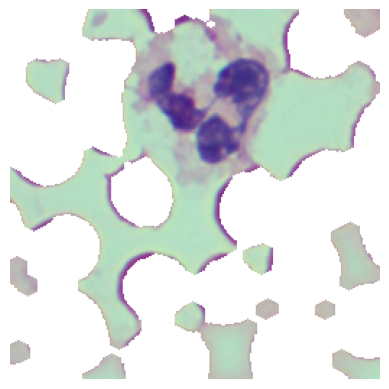

In [5]:
result_wbc = img.copy()
result_wbc[rbc_mask == 255] = 255
result_wbc_rbg = cv2.cvtColor(result_wbc, cv2.COLOR_BGR2RGB)
plt.imshow(result_wbc_rbg)
plt.axis('off')
plt.show()

Mow, we will process each one

# RBC processing

In [6]:
#Make process frequen
def median_dilation(img, iters = 1):
    #Median first
    img_median = cv2.medianBlur(img, 5)
    kernel = np.ones((3, 3), np.uint8)
    while iters > 0:
        #Dilation
        img_median = cv2.dilate(img_median, kernel, iterations=1)
        #Median again
        img_median = cv2.medianBlur(img_median, 5)
        iters -= 1
    return img_median

Turn to gray and binary image

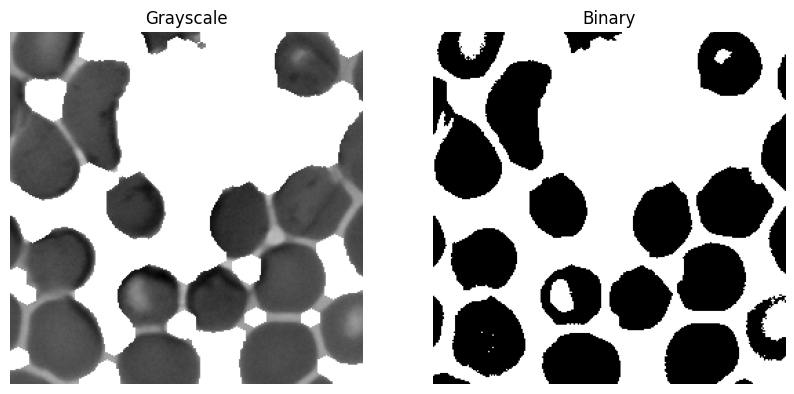

In [7]:
img_rbc_gray = cv2.cvtColor(result_rbc, cv2.COLOR_RGB2GRAY)
_, img_rbc_binary = cv2.threshold(img_rbc_gray, 135, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10,5))

# Ảnh grayscale
plt.subplot(1, 2, 1)
plt.imshow(img_rbc_gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

# Ảnh binary
plt.subplot(1, 2, 2)
plt.imshow(img_rbc_binary, cmap='gray')
plt.title("Binary")
plt.axis("off")

plt.show()

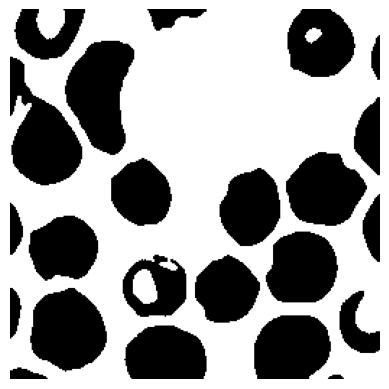

In [8]:
img_test = img_rbc_gray.copy()
img_test[img_rbc_gray >= 135] = 255 
img_test[img_rbc_gray <= 80] = 255
img_test = median_dilation(img_test, 0)

_, img_rbc_binary = cv2.threshold(img_test, 140, 255, cv2.THRESH_BINARY)
plt.imshow(img_rbc_binary, cmap="gray")
plt.axis("off")
plt.show()

Try use median + dilation

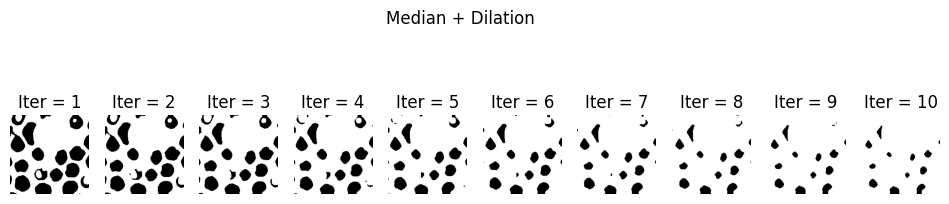

In [9]:
iters = 10
plt.figure(figsize=(12,3))

for i in range(iters):
    img_rbc_median_dilation = median_dilation(img_rbc_binary, i+1)
    
    plt.subplot(1, iters, i+1)
    plt.imshow(img_rbc_median_dilation, cmap='gray')
    plt.title(f"Iter = {i+1}")
    plt.axis("off")

plt.suptitle("Median + Dilation")
plt.show()

Using Canny to detect edges 

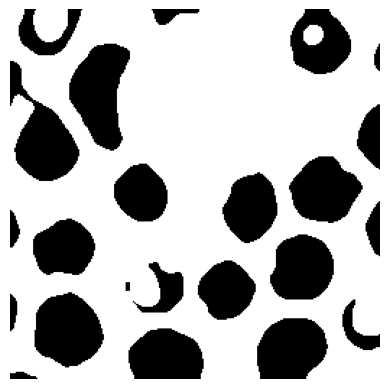

In [10]:
img_rbc_median_dilation = median_dilation(img_rbc_binary,2)

plt.imshow(img_rbc_median_dilation, cmap='gray')
plt.axis('off')
plt.show()

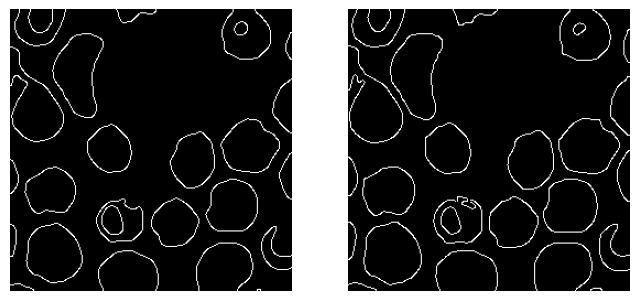

In [11]:
img_rbc_median_dilation = median_dilation(img_rbc_binary, 1)
#Use Canny Edge Detection
edges_rbc = cv2.Canny(img_rbc_median_dilation, 50, 150)

plt.figure(figsize=(8,4))
#Display Edges
plt.subplot(1,2,1)
plt.imshow(edges_rbc, cmap='gray')
plt.axis('off')

edges = cv2.Canny(img_test, 50, 150)
plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.axis('off')
plt.show()

Use BFS to find lines and detect object

In [12]:
#Sử dụng thành phần liên thông để tìm các contour
graph = edges_rbc.copy()

def get_neighbors(graph, vertex):
    neighbors = []
    x, y = vertex
    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            if dx == 0 and dy == 0:
                continue
            nx, ny = x + dx, y + dy
            if 0 <= nx < graph.shape[0] and 0 <= ny < graph.shape[1] and graph[nx, ny] == 255:
                neighbors.append((nx, ny))
    return neighbors

def bfs(graph, start):
    visited = set()
    queue = [start]
    while queue:
        vertex = queue.pop(0)
        if vertex not in visited:
            visited.add(vertex)
            neighbors = get_neighbors(graph, vertex)
            queue.extend(neighbors)
    return visited

def find_connected_components(graph):
    visited = set()
    components = []
    for x in range(graph.shape[0]):
        for y in range(graph.shape[1]):
            if graph[x, y] == 255 and (x, y) not in visited:
                component = bfs(graph, (x, y))
                visited.update(component)
                components.append(component)
    return components

rbc_components = find_connected_components(graph)

In [13]:
def from_bin_to_component(img, iters):
    processed_img = median_dilation(img, iters)
    edges = cv2.Canny(processed_img, 50, 100)
    graph = edges.copy()
    components = find_connected_components(graph)
    return components

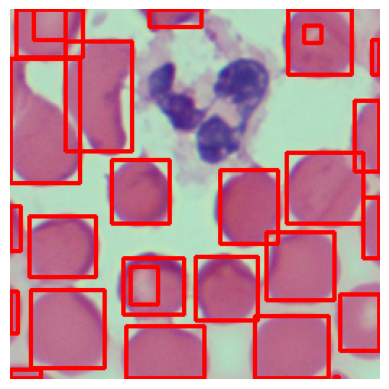

In [14]:
def draw_boundingboxes(image, components):
    for component in components:
        xs = [vertex[0] for vertex in component]
        ys = [vertex[1] for vertex in component]
        x_min, x_max = min(xs), max(xs)
        y_min, y_max = min(ys), max(ys)
        cv2.rectangle(image, (y_min, x_min), (y_max, x_max), (255, 0, 0), 2)
#Draw bounding boxes on the original image
img_with_boxes = img_rgb.copy()
draw_boundingboxes(img_with_boxes, rbc_components)
#Display Image with Bounding Boxes
plt.imshow(img_with_boxes)
plt.axis('off')
plt.show()



We will filter some boxes with small size

In [15]:
#Now we will filter the bounding boxes based on their size to remove noise
def filter_boundingboxes(components, min_size=100, max_size=10000):
    filtered_components = []
    for component in components:
        xs = [vertex[0] for vertex in component]
        ys = [vertex[1] for vertex in component]
        x_min, x_max = min(xs), max(xs)
        y_min, y_max = min(ys), max(ys)
        x_delta = x_max -x_min
        y_delta = y_max -y_min
        if min_size <= x_delta +y_delta  <= max_size:
            filtered_components.append(component)
    return filtered_components

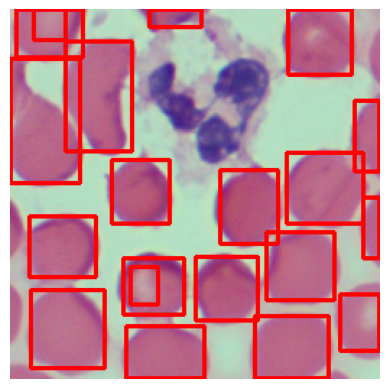

In [16]:
#Filter bounding boxes
filtered_rbc_components = filter_boundingboxes(rbc_components, min_size=40, max_size=140)
#Draw filtered bounding boxes on the original image
img_with_filtered_boxes = img_rgb.copy()
draw_boundingboxes(img_with_filtered_boxes, filtered_rbc_components)
#Display Image with Filtered Bounding Boxes
plt.imshow(img_with_filtered_boxes)
plt.axis('off')
plt.show()

In [17]:
def process_filter(img, iters=2, min_size=40, max_size=300):
    components = from_bin_to_component(img, iters)
    filtered_components = filter_boundingboxes(components, min_size, max_size)
    return filtered_components

Process overlap boxes by using Non Maximum Suppression

In [18]:
#We using Non Maximum Suppression to further refine the bounding boxes
def compute_iou(box1, box2):
    x1_min, y1_min, x1_max, y1_max = box1
    x2_min, y2_min, x2_max, y2_max = box2
    
    # Calculate intersection
    inter_x_min = max(x1_min, x2_min)
    inter_y_min = max(y1_min, y2_min)
    inter_x_max = min(x1_max, x2_max)
    inter_y_max = min(y1_max, y2_max)
    
    if inter_x_max < inter_x_min or inter_y_max < inter_y_min:
        return 0.0  # No overlap
    
    inter_area = (inter_x_max - inter_x_min) * (inter_y_max - inter_y_min)
    
    # Calculate union
    box1_area = (x1_max - x1_min) * (y1_max - y1_min)
    box2_area = (x2_max - x2_min) * (y2_max - y2_min)
    
    union_area = box1_area + box2_area - inter_area
    
    return inter_area / union_area

def non_maximum_suppression(components, overlap_threshold=0.5, boxes = False):
    if len(components) == 0:
        return []
    
    if not boxes:
        # Extract bounding boxes
        boxes = []
        for component in components:
            xs = [vertex[0] for vertex in component]
            ys = [vertex[1] for vertex in component]
            x_min, x_max = min(xs), max(xs)
            y_min, y_max = min(ys), max(ys)
            boxes.append((x_min, y_min, x_max, y_max))
    else:
        boxes = []
        for component in components:
            x_min, y_min, x_max, y_max = component
            boxes.append((x_min, y_min, x_max, y_max))
    
    # Sort boxes by area
    boxes.sort(key=lambda x: (x[2] - x[0]) * (x[3] - x[1]), reverse=True)
    
    selected_boxes = []
    
    while boxes:
        current_box = boxes.pop(0)
        selected_boxes.append(current_box)
        
        boxes = [box for box in boxes if compute_iou(current_box, box) < overlap_threshold]
    
    return selected_boxes

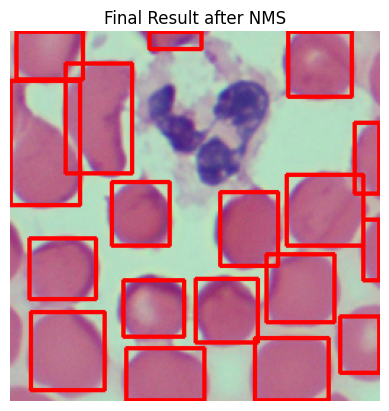

In [19]:
#Apply Non Maximum Suppression
final_boxes = non_maximum_suppression(filtered_rbc_components, overlap_threshold=0.3)
#Draw final bounding boxes after NMS
img_final = img_rgb.copy()
for box in final_boxes:
    x_min, y_min, x_max, y_max = box
    cv2.rectangle(img_final, (y_min, x_min), (y_max, x_max), (255, 0, 0), 2)
#Display final result
plt.imshow(img_final)
plt.title('Final Result after NMS')
plt.axis('off')
plt.show()

Some boxes may lie in the bigger ones so we need remove it

In [20]:
#Case: bounding boxes lie in a boxes, remove
def remove_nested_boxes(boxes, threshold_):
    non_nested_boxes = []
    for box in boxes:
        x_min, y_min, x_max, y_max = box
        is_nested = False
        for other_box in boxes:
            if box == other_box:
                continue
            ox_min, oy_min, ox_max, oy_max = other_box
            if x_min >= ox_min and y_min >= oy_min and x_max <= ox_max and y_max <= oy_max:
                is_nested = True
                break
        if not is_nested:
            non_nested_boxes.append(box)
    return non_nested_boxes

In [21]:
def compute_intersection(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter_w = max(0, xB - xA)
    inter_h = max(0, yB - yA)
    return inter_w * inter_h


def box_area(box):
    return (box[2] - box[0]) * (box[3] - box[1])


def remove_nested_boxes(boxes, threshold=0.8):
    """
    threshold: % diện tích của box bị overlap để coi là nested
    """
    keep_boxes = []

    for i, box in enumerate(boxes):
        area_box = box_area(box)
        is_nested = False

        for j, other_box in enumerate(boxes):
            if i == j:
                continue

            inter = compute_intersection(box, other_box)

            # tỷ lệ overlap trên chính box
            overlap_ratio = inter / (area_box + 1e-6)
            #print(overlap_ratio)

            if overlap_ratio > threshold:
                # box này gần như nằm trong box kia
                is_nested = True
                break

        if not is_nested:
            keep_boxes.append(box)

    return keep_boxes

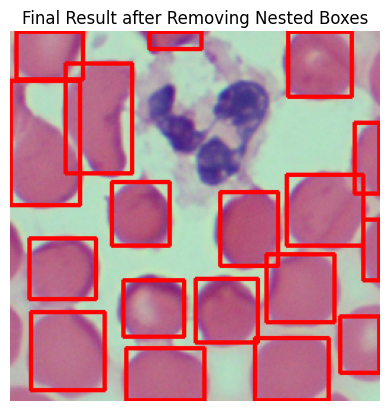

In [22]:
#Remove nested boxes
final_boxes_non_nested = remove_nested_boxes(final_boxes, 0.7)
#Draw non-nested bounding boxes
img_non_nested = img_rgb.copy()
for box in final_boxes_non_nested:
    x_min, y_min, x_max, y_max = box
    cv2.rectangle(img_non_nested, (y_min, x_min), (y_max, x_max), (255, 0, 0), 2)
#Display non-nested result
plt.imshow(img_non_nested)
plt.title('Final Result after Removing Nested Boxes')
plt.axis('off')
plt.show()

Now, we will summary all to one function

In [23]:
def process_normal_box_for_rbc(image_rbc):
    img_gray = cv2.cvtColor(image_rbc, cv2.COLOR_RGB2GRAY)
    img_gray[img_gray >= 135] = 255
    img_gray[img_gray <= 80] = 255

    img_gray = median_dilation(img_gray, 0)
    _, img_binary = cv2.threshold(img_gray, 130, 255, cv2.THRESH_BINARY)
    
    #Process normal boxes
    egdes = cv2.Canny(img_binary, 50, 150)
    component_1 = find_connected_components(egdes)
    component_1 = filter_boundingboxes(component_1, 40, 140)
    normal_boxes = non_maximum_suppression(component_1, 0.3)
    normal_boxes = remove_nested_boxes(normal_boxes, 0.7)

    component_1 = normal_boxes

    return component_1

def process_overlap_box_for_rbc(image_rbc):
    img_gray = cv2.cvtColor(image_rbc, cv2.COLOR_RGB2GRAY)
    img_gray[img_gray >= 135] = 255
    img_gray[img_gray <= 80]

    img_gray = median_dilation(img_gray, 1)
    _, img_binary = cv2.threshold(img_gray, 125, 255, cv2.THRESH_BINARY)
    
    #Process normal boxes
    overlap_boxes = process_filter(img_binary, 2, 60, 115)
    overlap_boxes = non_maximum_suppression(overlap_boxes, 0.3)
    overlap_boxes = remove_nested_boxes(overlap_boxes)
    

    return overlap_boxes
def process_bounding_box_for_rbc(image_rbc):
    normal = process_normal_box_for_rbc(image_rbc)
    overlap = process_overlap_box_for_rbc(image_rbc)

    total = overlap + normal
    total = non_maximum_suppression(total, boxes= True)
    total = remove_nested_boxes(total)

    img_h = image_rbc.shape[0]
    img_w = image_rbc.shape[1]
    relaxed_boxes = []
    for box in total:
        x_min, y_min, x_max, y_max = box
        relaxed_box = (
            max(0, x_min - 5),
            max(0, y_min - 5),
            min(img_w, x_max + 5),   # fix: width for x, height for y
            min(img_h, y_max + 5),
        )
        relaxed_boxes.append(relaxed_box)

    return relaxed_boxes

def process_mask(image_src):
    img = cv2.imread(image_src)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    # Hue đỏ/hồng nằm ở 2 đầu vòng màu HSV (0-15 và 155-180)
    rbc_mask1 = cv2.inRange(img_hsv, np.array([0,   40, 100]), np.array([15,  255, 255]))
    rbc_mask2 = cv2.inRange(img_hsv, np.array([155, 40, 100]), np.array([180, 255, 255]))
    rbc_mask  = cv2.bitwise_or(rbc_mask1, rbc_mask2)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    rbc_mask = cv2.morphologyEx(rbc_mask, cv2.MORPH_CLOSE, kernel, iterations=3)
    rbc_mask = cv2.morphologyEx(rbc_mask, cv2.MORPH_OPEN,  kernel, iterations=1)

    rbc_img = img.copy()
    rbc_img[rbc_mask == 0] = 255

    wbc_img = img.copy()
    wbc_img[rbc_mask == 255] = 255

    return rbc_img, wbc_img

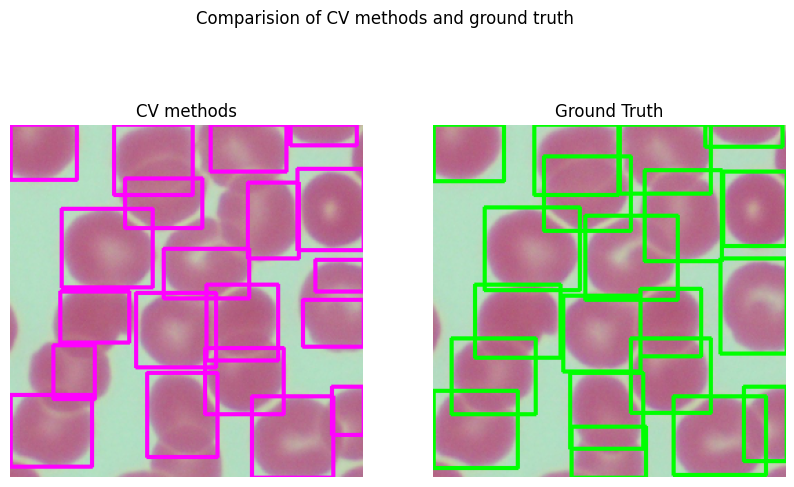

In [24]:
 #Test the function
image_name = "image-10.png"
image = 'dataset/BDS/images/'+image_name
rbc_img, wbc_img = process_mask(image)
final_boxes = process_bounding_box_for_rbc(rbc_img)
#Draw final bounding boxes on the original image

img_with_final_boxes = cv2.cvtColor(cv2.imread(image), cv2.COLOR_BGR2RGB)
for box in final_boxes:
    x_min, y_min, x_max, y_max = box
    cv2.rectangle(img_with_final_boxes, (y_min, x_min), (y_max, x_max), (255, 0, 255), 2)
#Display Image with Final Bounding Boxes
plt.figure(figsize=(10,6))
plt.suptitle("Comparision of CV methods and ground truth")

plt.subplot(1,2,1)
plt.imshow(img_with_final_boxes)
plt.title("CV methods")
plt.axis('off')
#From annotations.csv file, we will read the bounding box coordinates and draw them on the image 2
import pandas as pd
annotations = pd.read_csv('dataset/BDS/annotations.csv')
#Filter annotations for image-2.png
image_annotations = annotations[annotations['image'] == image_name]
#Draw annotated bounding boxes on the original image
img_with_annotations = cv2.cvtColor(cv2.imread(image), cv2.COLOR_BGR2RGB)
for index, row in image_annotations.iterrows():
    x_min, y_min, x_max, y_max = int(row['xmin']), int(row['ymin']), int(row['xmax']), int(row['ymax'])
    cv2.rectangle(img_with_annotations, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
#Display Image with Annotated Bounding Boxes
plt.subplot(1,2,2)
plt.imshow(img_with_annotations)
plt.axis('off')
plt.title("Ground Truth")
plt.show()

# WBC Processing

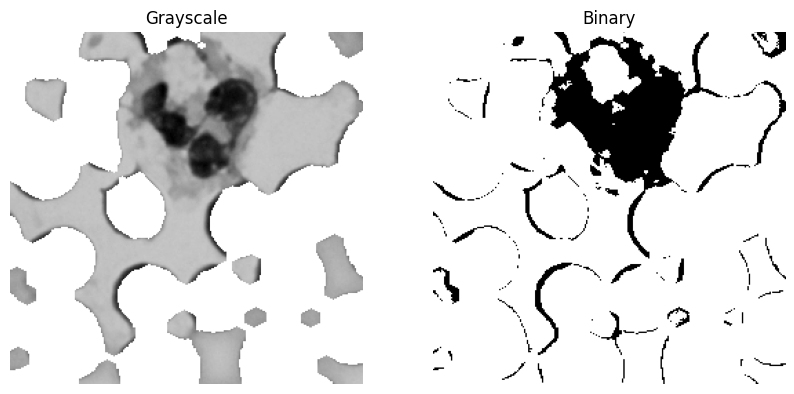

In [25]:
img_wbc_gray = cv2.cvtColor(result_wbc, cv2.COLOR_RGB2GRAY)
_, img_wbc_binary = cv2.threshold(img_wbc_gray, 180, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10,5))

# Ảnh grayscale
plt.subplot(1, 2, 1)
plt.imshow(img_wbc_gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

# Ảnh binary
plt.subplot(1, 2, 2)
plt.imshow(img_wbc_binary, cmap='gray')
plt.title("Binary")
plt.axis("off")

plt.show()

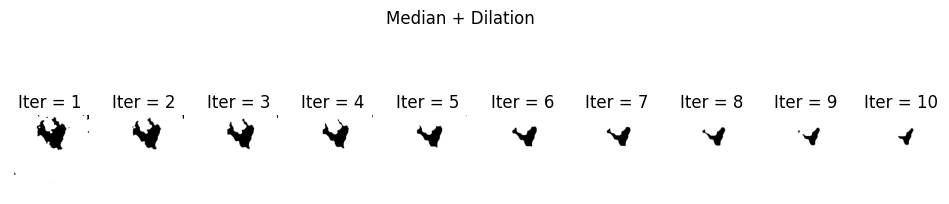

In [26]:
iters = 10
plt.figure(figsize=(12,3))

for i in range(iters):
    img_wbc_median_dilation = median_dilation(img_wbc_binary, i+1)
    
    plt.subplot(1, iters, i+1)
    plt.imshow(img_wbc_median_dilation, cmap='gray')
    plt.title(f"Iter = {i+1}")
    plt.axis("off")

plt.suptitle("Median + Dilation")
plt.show()

SUM UP

In [27]:
def process_bounding_box_for_wbc(img_wbc):
    img_wbc_gray = cv2.cvtColor(img_wbc, cv2.COLOR_RGB2GRAY)
    _, img_wbc_binary = cv2.threshold(img_wbc_gray, 180, 255, cv2.THRESH_BINARY)
    component = process_filter(img_wbc_binary,1,40,1000)
    
    final_boxes = non_maximum_suppression(component)
    final_boxes = remove_nested_boxes(final_boxes)
    relaxed_boxes = []
    img_h = img_wbc.shape[0]
    img_w = img_wbc.shape[1]
    for box in final_boxes:
        x_min, y_min, x_max, y_max = box
        relaxed_box = (
            max(0, x_min - 15),
            max(0, y_min - 15),
            min(img_w, x_max + 15),   # fix: width for x, height for y
            min(img_h, y_max + 15),
        )
        relaxed_boxes.append(relaxed_box)
    return final_boxes

def process_bounding_box(rbc_img, wbc_img):
    rbc_boxes = process_bounding_box_for_rbc(rbc_img)
    wbc_boxes = process_bounding_box_for_wbc(wbc_img)
    return rbc_boxes + wbc_boxes

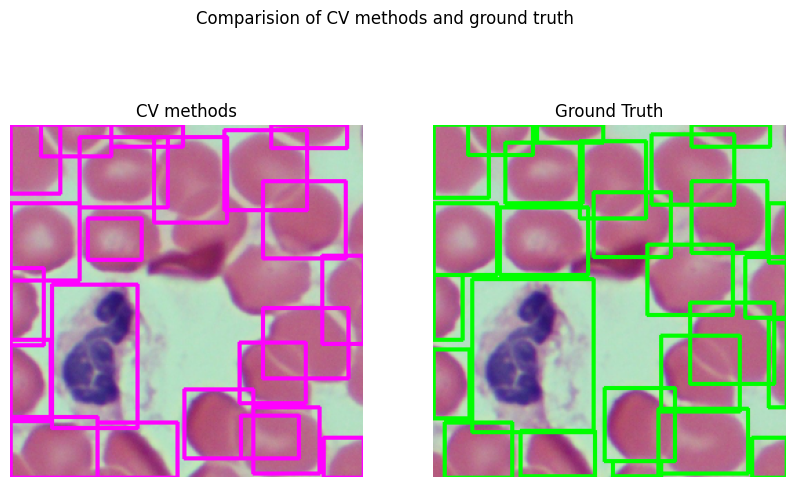

In [29]:
 #Test the function
image_name = "image-7.png"
image = 'dataset/BDS/images/'+image_name
rbc_img, wbc_img = process_mask(image)
final_boxes = process_bounding_box(rbc_img,wbc_img)
#Draw final bounding boxes on the original image

img_with_final_boxes = cv2.cvtColor(cv2.imread(image), cv2.COLOR_BGR2RGB)
for box in final_boxes:
    x_min, y_min, x_max, y_max = box
    cv2.rectangle(img_with_final_boxes, (y_min, x_min), (y_max, x_max), (255, 0, 255), 2)
#Display Image with Final Bounding Boxes
plt.figure(figsize=(10,6))
plt.suptitle("Comparision of CV methods and ground truth")

plt.subplot(1,2,1)
plt.imshow(img_with_final_boxes)
plt.title("CV methods")
plt.axis('off')
#From annotations.csv file, we will read the bounding box coordinates and draw them on the image 2
import pandas as pd
annotations = pd.read_csv('dataset/BDS/annotations.csv')
#Filter annotations for image-2.png
image_annotations = annotations[annotations['image'] == image_name]
#Draw annotated bounding boxes on the original image
img_with_annotations = cv2.cvtColor(cv2.imread(image), cv2.COLOR_BGR2RGB)
for index, row in image_annotations.iterrows():
    x_min, y_min, x_max, y_max = int(row['xmin']), int(row['ymin']), int(row['xmax']), int(row['ymax'])
    cv2.rectangle(img_with_annotations, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
#Display Image with Annotated Bounding Boxes
plt.subplot(1,2,2)
plt.imshow(img_with_annotations)
plt.axis('off')
plt.title("Ground Truth")
plt.show()